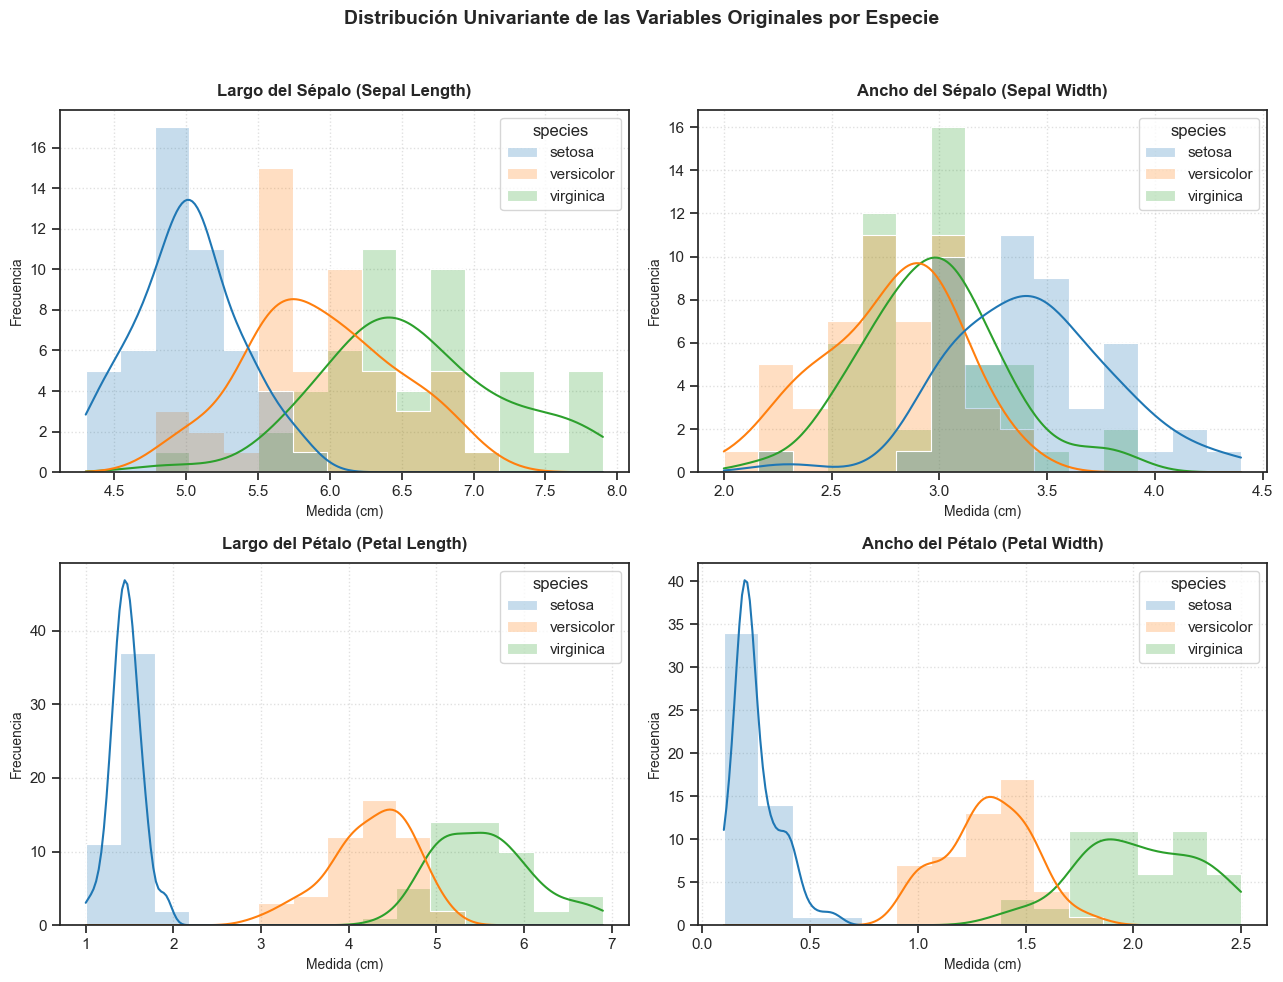

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# 1. Cargar el conjunto de datos Iris
iris_raw = load_iris()
iris = pd.DataFrame(iris_raw.data, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
iris['species'] = pd.Categorical.from_codes(iris_raw.target, iris_raw.target_names)

# Variables continuas originales
variables_originales = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
titulos = [
    'Largo del Sépalo (Sepal Length)', 
    'Ancho del Sépalo (Sepal Width)', 
    'Largo del Pétalo (Petal Length)', 
    'Ancho del Pétalo (Petal Width)'
]

# Configuración de la figura en disposición 2x2
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

# Mantenimiento de la paleta de colores para coherencia gráfica
palette = {'setosa': '#1f77b4', 'versicolor': '#ff7f0e', 'virginica': '#2ca02c'}

sns.set_theme(style="ticks")

# 2. Iteración para generación de histogramas con KDE
for i, var in enumerate(variables_originales):
    sns.histplot(
        data=iris,
        x=var,
        hue='species',
        kde=True,
        element='step',
        palette=palette,
        ax=axes[i],
        edgecolor='white',
        linewidth=0.8,
        bins=15
    )
    axes[i].set_title(titulos[i], fontsize=12, fontweight='bold', pad=10)
    axes[i].set_xlabel('Medida (cm)', fontsize=10)
    axes[i].set_ylabel('Frecuencia', fontsize=10)
    axes[i].grid(True, linestyle=':', alpha=0.6)

fig.suptitle('Distribución Univariante de las Variables Originales por Especie', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Carga del conjunto de datos
# seaborn proporciona la versión clásica de Iris (nombres en snake_case)
iris = sns.load_dataset('iris')

# 2. Ingenieria de características: Codificación indicador (dummy/one-hot manual)
# Equivale al mutate() + ifelse() de dplyr mediante evaluación vectorial
iris_codificado = iris.copy()
iris_codificado['x_setosa'] = (iris_codificado['species'] == 'setosa').astype(int)
iris_codificado['x_versicolor'] = (iris_codificado['species'] == 'versicolor').astype(int)

# 3. Selección del subconjunto de variables
# Equivale a select() de dplyr
columnas_analisis = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'x_setosa', 'x_versicolor']
datos_analisis = iris_codificado[columnas_analisis]

In [4]:
# 4. Vector de medias vectoriales
vector_medias = datos_analisis.mean()
print("--- Vector de Medias ---")
print(vector_medias)
print("\n")

# 4. Vector de desvios
vector_desvios = datos_analisis-vector_medias
print("--- Vector de Desvios ---")
print(vector_desvios)
print("\n")

# 5. Matriz de Covarianza (muestra)
matriz_cov = datos_analisis.cov()
print("--- Matriz de Covarianza (Redondeada a 3 decimales) ---")
print(matriz_cov.round(3))
print("\n")

# 6. Matriz de Correlación (Pearson)
matriz_cor = datos_analisis.corr()
print("--- Matriz de Correlación (Redondeada a 3 decimales) ---")
print(matriz_cor.round(3))

--- Vector de Medias ---
sepal_length    5.843333
sepal_width     3.057333
petal_length    3.758000
petal_width     1.199333
x_setosa        0.333333
x_versicolor    0.333333
dtype: float64


--- Vector de Desvios ---
     sepal_length  sepal_width  petal_length  petal_width  x_setosa  \
0       -0.743333     0.442667        -2.358    -0.999333  0.666667   
1       -0.943333    -0.057333        -2.358    -0.999333  0.666667   
2       -1.143333     0.142667        -2.458    -0.999333  0.666667   
3       -1.243333     0.042667        -2.258    -0.999333  0.666667   
4       -0.843333     0.542667        -2.358    -0.999333  0.666667   
..            ...          ...           ...          ...       ...   
145      0.856667    -0.057333         1.442     1.100667 -0.333333   
146      0.456667    -0.557333         1.242     0.700667 -0.333333   
147      0.656667    -0.057333         1.442     0.800667 -0.333333   
148      0.356667     0.342667         1.642     1.100667 -0.333333   
1

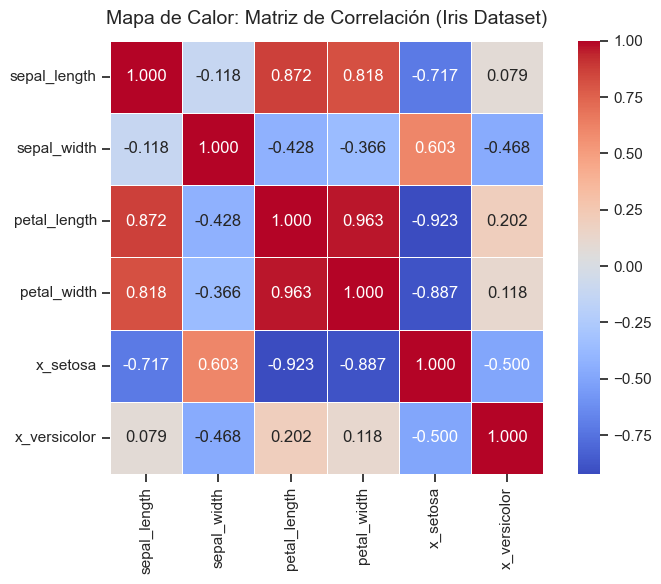

In [7]:
# Configuración del gráfico
plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_cor, 
    annot=True, 
    fmt=".3f", 
    cmap="coolwarm", 
    cbar=True,
    linewidths=0.5,
    square=True
)

plt.title("Mapa de Calor: Matriz de Correlación (Iris Dataset)", fontsize=14, pad=12)
plt.tight_layout()
plt.savefig("heatmap_correl.png", dpi=300)
plt.show()

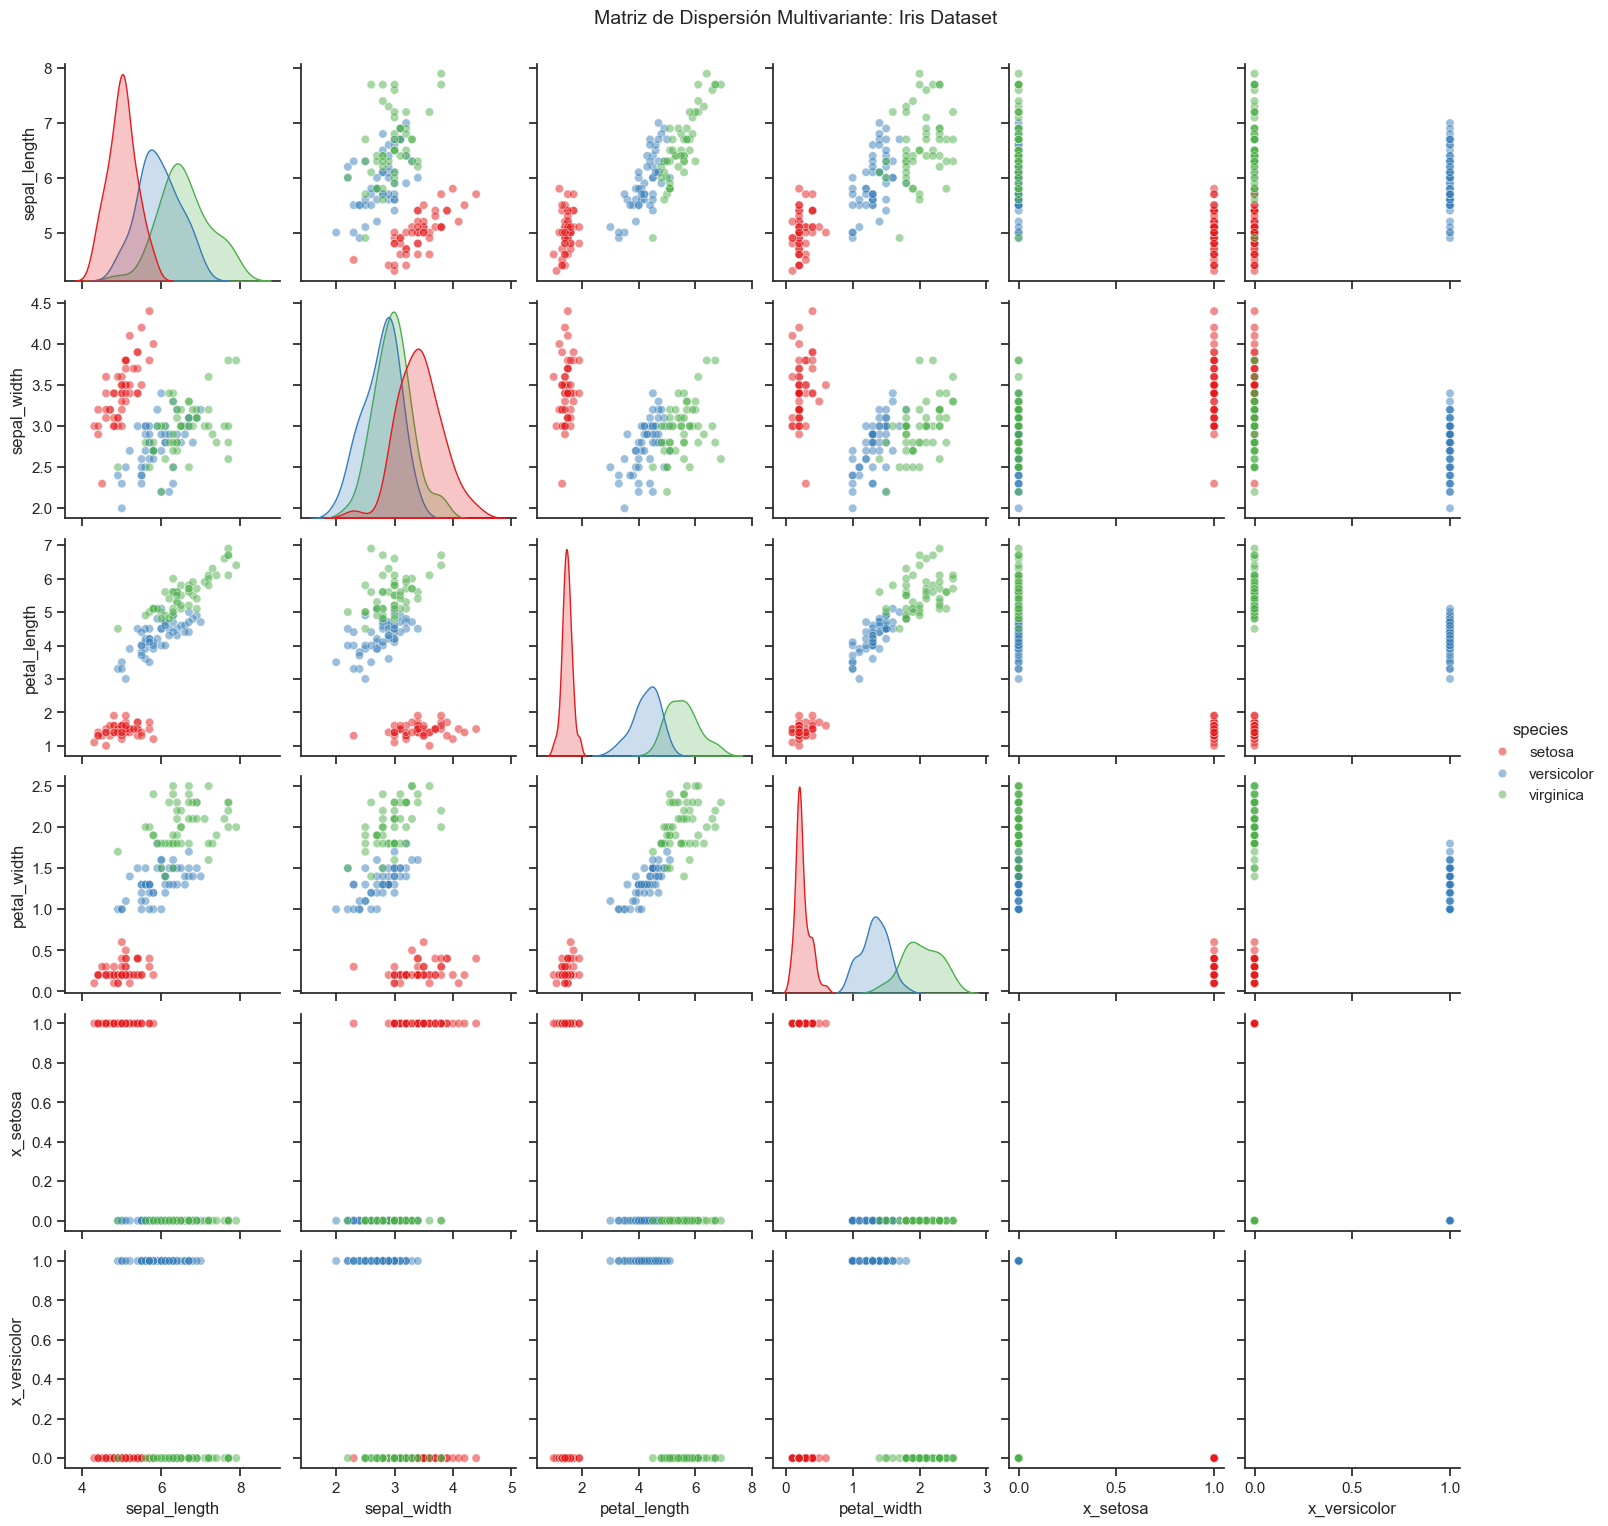

In [5]:
# 7. Matriz de dispersión multivariante (Equivalente a GGally::ggpairs)
sns.set_theme(style="ticks")
grafico_multivariante = sns.pairplot(
    iris_codificado,
    hue='species',
    palette='Set1',
    plot_kws={'alpha': 0.5},
    diag_kind='kde'  # Estimación de densidad kernel en la diagonal
)

grafico_multivariante.fig.suptitle(
    "Matriz de Dispersión Multivariante: Iris Dataset", 
    y=1.02, 
    fontsize=14
)

plt.show()

# Análisis de componentes principales

In [8]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [24]:
# Standardize variables (z-score normalization for PCA based on correlation structure)
scaler = StandardScaler()
datos_analisis_scaled = scaler.fit_transform(datos_analisis)

# PCA
pca = PCA()
datos_analisis_pca = pca.fit_transform(datos_analisis_scaled)

# 2. Scree Plot
eigenvalues = pca.explained_variance_  # Autovalores (\lambda_i)
var_exp = pca.explained_variance_ratio_
cum_var_exp = np.cumsum(var_exp)

print("Autovalor:", eigenvalues.round(4))
print("Var exp:", var_exp.round(4))
print("Cum var:", cum_var_exp.round(4))
print("Loadings PC1:", loadings[:, 0].round(3))
print("Loadings PC2:", loadings[:, 1].round(3))

Autovalor: [3.9434 1.3506 0.5525 0.1564 0.0238 0.0135]
Var exp: [0.6528 0.2236 0.0915 0.0259 0.0039 0.0022]
Cum var: [0.6528 0.8764 0.9679 0.9938 0.9978 1.    ]
Loadings PC1: [-0.829  0.559 -0.976 -0.939  0.98  -0.386]
Loadings PC2: [-0.436 -0.645 -0.199 -0.266 -0.145  0.784]


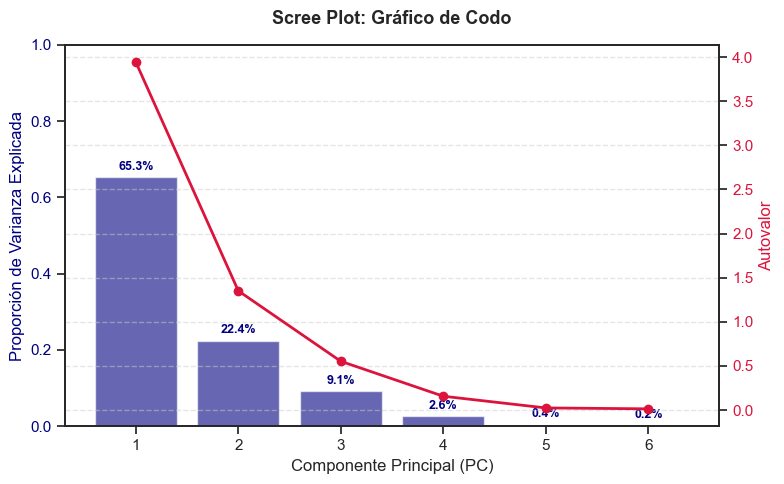

In [26]:
fig, ax1 = plt.subplots(figsize=(8, 5))

# Bar chart for individual variance
bars = ax1.bar(range(1, len(var_exp) + 1), var_exp, alpha=0.6, color='navy', label='Varianza Individual')
ax1.set_xlabel('Componente Principal (PC)', fontsize=12)
ax1.set_ylabel('Proporción de Varianza Explicada', fontsize=12, color='navy')
ax1.tick_params(axis='y', labelcolor='navy')
ax1.set_xticks(range(1, len(var_exp) + 1))
ax1.set_ylim(0, 1)

# Line chart for cumulative variance
ax2 = ax1.twinx()
line = ax2.plot(range(1, len(var_exp) + 1), eigenvalues, color='crimson', marker='o', linewidth=2, label='Autovalor')
ax2.set_ylabel('Autovalor', fontsize=12, color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
#ax2.set_ylim(0, 1.05)

# Annotate percentages
for i, (v, c) in enumerate(zip(var_exp, cum_var_exp)):
    ax1.text(i+1, v + 0.02, f"{v*100:.1f}%", ha='center', fontsize=9, color='navy', fontweight='bold')

plt.title('Scree Plot: Gráfico de Codo', fontsize=13, fontweight='bold', pad=15)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('scree_plot.png', dpi=300)
#plt.close()


Por criterio de Kaiser las componentes 1 y 2 tienen autovalores mayores a 1.

# Analizamos datos en espacio reducido R2

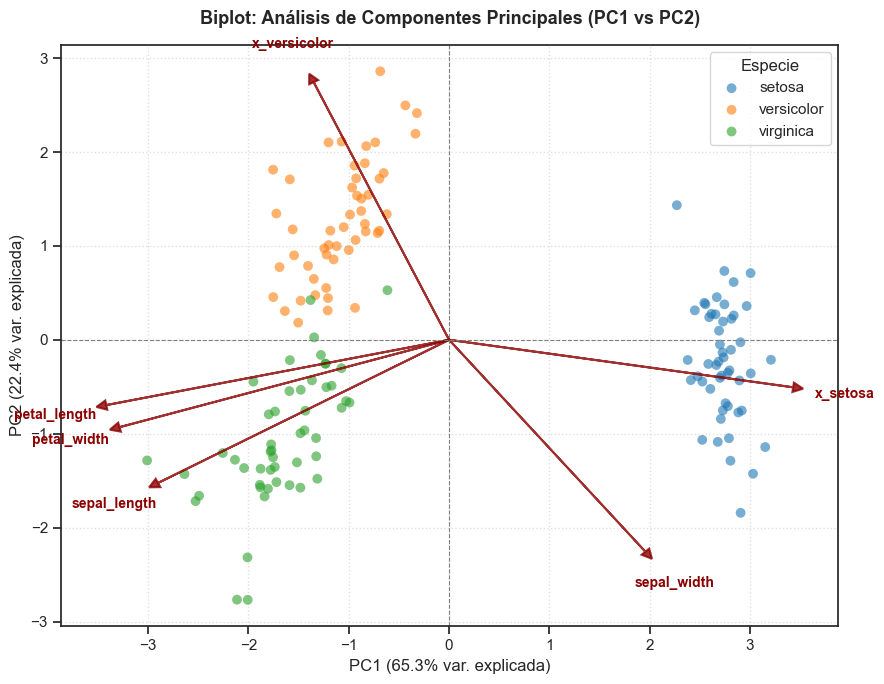

In [19]:
# 3. Biplot (PC1 vs PC2)
plt.figure(figsize=(9, 7))
# Scatter plot of scores
species_colors = {'setosa': '#1f77b4', 'versicolor': '#ff7f0e', 'virginica': '#2ca02c'}
for sp in iris['species'].unique():
    mask = iris['species'] == sp
    plt.scatter(datos_analisis_pca[mask, 0], datos_analisis_pca[mask, 1], label=sp, alpha=0.6, c=species_colors[sp], edgecolors='none', s=50)

# Loadings (eigenvectors * sqrt(eigenvalues)) or raw loadings
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# Scale factor for display
scale = 3.5

for i, feature in enumerate(columnas_analisis):
    plt.arrow(0, 0, loadings[i, 0]*scale, loadings[i, 1]*scale, 
              color='darkred', alpha=0.8, head_width=0.1, head_length=0.1, linewidth=1.5)
    # Adjust annotation text positioning slightly
    plt.text(loadings[i, 0]*scale * 1.15, loadings[i, 1]*scale * 1.15, feature, 
             color='darkred', ha='center', va='center', fontweight='bold', fontsize=10)

plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)

plt.xlabel(f'PC1 ({var_exp[0]*100:.1f}% var. explicada)', fontsize=12)
plt.ylabel(f'PC2 ({var_exp[1]*100:.1f}% var. explicada)', fontsize=12)
plt.title('Biplot: Análisis de Componentes Principales (PC1 vs PC2)', fontsize=13, fontweight='bold', pad=15)
plt.legend(title='Especie', loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('biplot.png', dpi=300)
#plt.close()

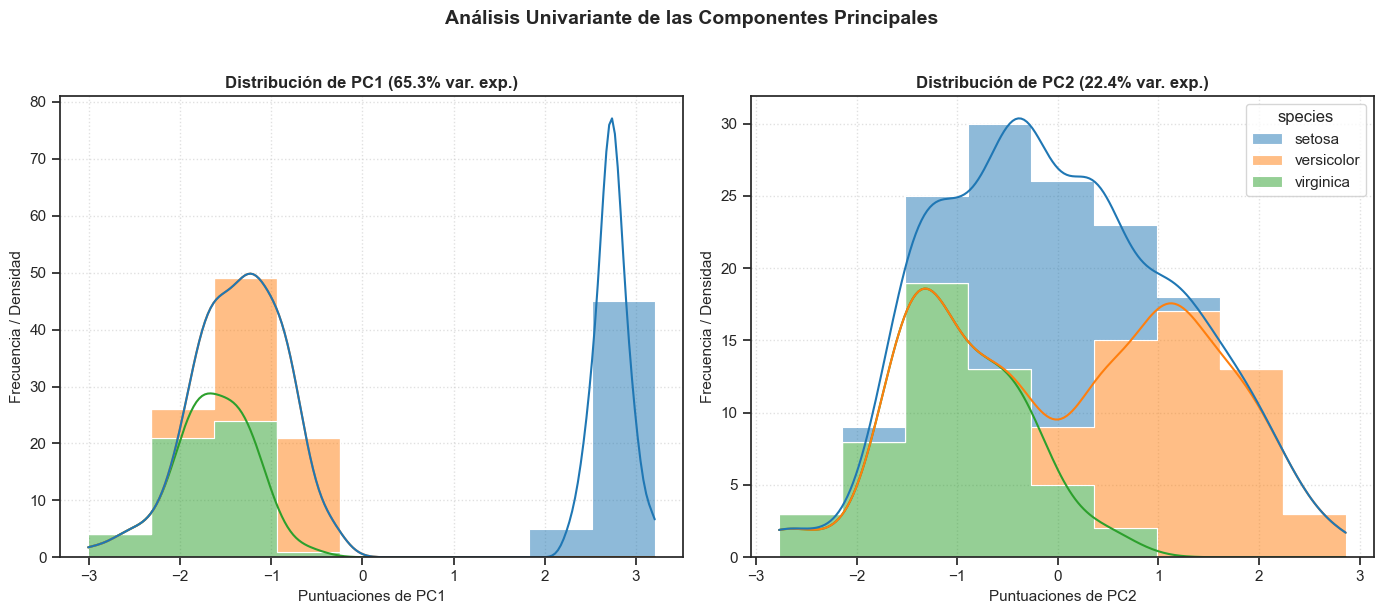

In [27]:
df_pca_scores = pd.DataFrame(datos_analisis_pca[:, :2], columns=['PC1', 'PC2'])
df_pca_scores['species'] = iris['species']

# 2. Creación de histogramas (en una figura con subplots)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.set_theme(style="ticks")

# Colores consistentes para especies (como en el biplot)
palette = {'setosa': '#1f77b4', 'versicolor': '#ff7f0e', 'virginica': '#2ca02c'}

# Histograma PC1
sns.histplot(
    data=df_pca_scores,
    x='PC1',
    hue='species',
    kde=True,
    multiple='stack', # Apilar para mostrar totales y desglose
    element='step',
    palette=palette,
    ax=axes[0],
    edgecolor='white',
    linewidth=0.8
)
axes[0].set_title(f'Distribución de PC1 ({var_exp[0]*100:.1f}% var. exp.)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Puntuaciones de PC1', fontsize=11)
axes[0].set_ylabel('Frecuencia / Densidad', fontsize=11)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Histograma PC2
sns.histplot(
    data=df_pca_scores,
    x='PC2',
    hue='species',
    kde=True,
    multiple='stack', # Apilar para mostrar totales y desglose
    element='step',
    palette=palette,
    ax=axes[1],
    edgecolor='white',
    linewidth=0.8
)
axes[1].set_title(f'Distribución de PC2 ({var_exp[1]*100:.1f}% var. exp.)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Puntuaciones de PC2', fontsize=11)
axes[1].set_ylabel('Frecuencia / Densidad', fontsize=11)
axes[1].grid(True, linestyle=':', alpha=0.6)

# Leyenda global
handles, labels = axes[0].get_legend_handles_labels()
axes[0].get_legend().remove() # Remover la leyenda interna
# axes[1].get_legend().remove() # seaborn_histplot ya las quita si hue está activo y hay subplots, a veces.

fig.suptitle('Análisis Univariante de las Componentes Principales', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('histogramas_pc1_pc2.png', dpi=300)
plt.show()